# Assignment

## Problem 

The objective of this project is to detect whether an image is a **real photograph** or a **photograph of a screen** (a "recapture") — e.g. someone photographing a phone/laptop/monitor showing a picture instead of taking a real photo of the real thing.

This version improves on the baseline approach by:

- Adding a **frequency-domain moire/periodicity feature** — the strongest available signal for this task. A photo of a screen has the screen's own pixel grid beating against the camera sensor's grid, which shows up as sharp, *localized* peaks in the FFT magnitude spectrum once the normal smooth radial (1/f) falloff shared by all natural photos is subtracted out. This is a more specific cue than a plain high/low frequency energy ratio.
- Adding gradient-orientation peakiness (grids concentrate edge energy at 0°/45°/90°), highlight/glare statistics, and richer color-skew features.
- Dropping the deep-features (EfficientNet) route — with only ~100 images, 1280-dim deep features overfit badly and underperformed the classical features in testing.
- Using a small **Logistic Regression + shallow Gradient Boosting soft-voting ensemble** instead of a single Random Forest — better suited to a small feature/sample regime.
- Evaluating with **Leave-One-Out cross-validation** instead of a single random train/test split, since with only ~100 images a random 80/20 split has high variance and can be misleading (a lucky split can show 94%, an unlucky one 86%, on the *same* model).

The final system predicts a probability between **0 and 1**, where

- **0 → Real Photo**
- **1 → Photo of a Screen**

In [1]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm import tqdm

from skimage.feature import local_binary_pattern
from skimage.measure import shannon_entropy

## Load Dataset

Expected folders:
- `Real/` for genuine photos
- `Fake/` for screen recaptures

In [2]:
DATASET = "Dataset"

real_path = os.path.join(DATASET, "Real")
fake_path = os.path.join(DATASET, "Fake")

In [3]:
real_images = sorted(os.listdir(real_path))
fake_images = sorted(os.listdir(fake_path))

print("Real Images  :", len(real_images))
print("Screen Images:", len(fake_images))

Real Images  : 51
Screen Images: 52


## Visualizing Sample Images

Preview a few examples from each class before feature extraction.

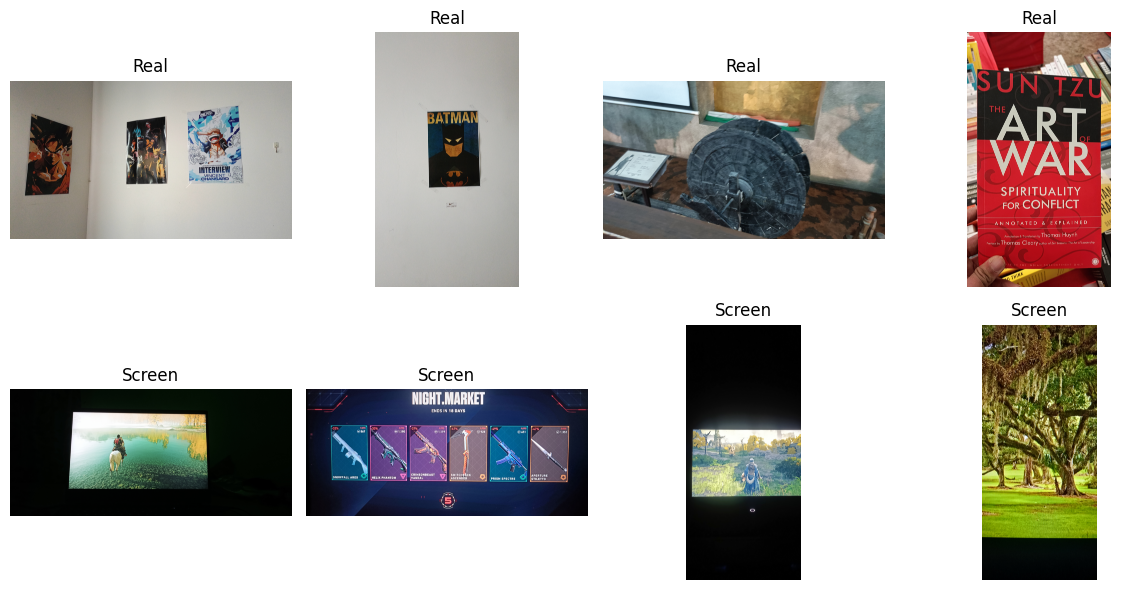

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):

    img = cv2.imread(os.path.join(real_path, real_images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[0, i].imshow(img)
    axes[0, i].set_title("Real")
    axes[0, i].axis("off")

    img = cv2.imread(os.path.join(fake_path, fake_images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[1, i].imshow(img)
    axes[1, i].set_title("Screen")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Image Loading

Load images with reduced JPEG decode first, then resize to `IMG_SIZE` for faster preprocessing.

In [5]:
IMG_SIZE = 512

def load_image(path, size=IMG_SIZE):
    img = cv2.imread(str(path), cv2.IMREAD_REDUCED_COLOR_2)
    if img is None or max(img.shape[:2]) < size:
        img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Could not read image: {path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    scale = size / max(h, w)
    if scale < 1.0:
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

    return img

In [6]:
real_sample = load_image(os.path.join(real_path, real_images[0]))
fake_sample = load_image(os.path.join(fake_path, fake_images[0]))

print(real_sample.shape)

(288, 512, 3)


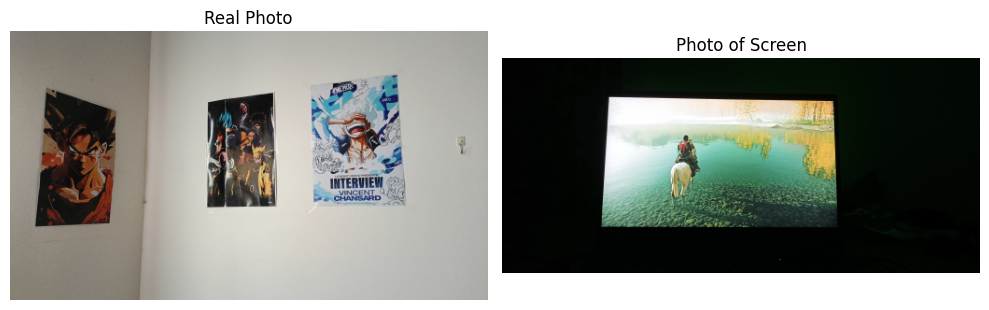

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(real_sample)
ax[0].set_title("Real Photo")
ax[0].axis("off")

ax[1].imshow(fake_sample)
ax[1].set_title("Photo of Screen")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## Feature Extraction

### 1. Sharpness (Laplacian variance)

In [8]:
def laplacian_variance(gray):
    return cv2.Laplacian(gray, cv2.CV_64F).var()

real_gray = cv2.cvtColor(real_sample, cv2.COLOR_RGB2GRAY)
fake_gray = cv2.cvtColor(fake_sample, cv2.COLOR_RGB2GRAY)

print("Real  :", laplacian_variance(real_gray))
print("Screen:", laplacian_variance(fake_gray))

Real  : 840.3525353798436
Screen: 581.5929584806763


### 2. Frequency / moire features — the key signal

The FFT residual highlights screen-grid beat patterns (moire) after removing the normal smooth radial trend.

In [9]:
def fft_moire_features(gray):
    g = gray.astype(np.float32)

    # window to reduce edge leakage
    win = np.outer(np.hanning(g.shape[0]), np.hanning(g.shape[1]))
    g = g * win

    f = np.fft.fft2(g)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    log_mag = np.log1p(magnitude)

    h, w = log_mag.shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2).astype(np.int32)
    max_r = dist.max()

    # radial average profile (natural images follow a smooth ~1/f falloff)
    radial_mean = np.bincount(dist.ravel(), log_mag.ravel()) / np.maximum(
        np.bincount(dist.ravel()), 1
    )
    radial_profile = radial_mean[dist]

    # residual after removing the expected smooth falloff -> isolates
    # sharp localized peaks (moire / periodic grid signal)
    residual = log_mag - radial_profile

    # ignore the very center (DC / low-freq content is huge in all images)
    mask_mid_high = dist > (0.05 * max_r)

    resid_mid_high = residual[mask_mid_high]
    peak_score = resid_mid_high.max() if resid_mid_high.size else 0.0
    peak_energy = np.mean(resid_mid_high > 3.0) if resid_mid_high.size else 0.0
    resid_std = resid_mid_high.std() if resid_mid_high.size else 0.0

    # classic low/high band energy ratio (kept from baseline)
    low_mask = dist < (0.08 * max_r)
    high_mask = dist > (0.25 * max_r)
    low_energy = magnitude[low_mask].mean()
    high_energy = magnitude[high_mask].mean()
    ratio = high_energy / (low_energy + 1e-8)

    return [
        magnitude.mean(),
        magnitude.std(),
        low_energy,
        high_energy,
        ratio,
        peak_score,
        peak_energy,
        resid_std,
    ]

print("Real  :", fft_moire_features(real_gray))
print("Screen:", fft_moire_features(fake_gray))

Real  : [np.float64(2816.0383174882936), np.float64(23807.319886521273), np.float64(49557.03940059284), np.float64(1694.7340293452403), np.float64(0.03419764477142322), np.float64(2.78864123846148), np.float64(0.0), np.float64(0.7659538293472444)]
Screen: [np.float64(1915.116213039753), np.float64(19143.748053517953), np.float64(35149.58643128823), np.float64(1186.2059526590706), np.float64(0.033747365846752544), np.float64(2.566849521812694), np.float64(0.0), np.float64(0.7099137030467391)]


### 3. Gradient orientation peakiness

Screen recaptures often show stronger orientation peaks from regular grid-like edges.

In [10]:
def gradient_features(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    angle = (np.arctan2(gy, gx) * 180 / np.pi) % 180

    # weight orientation histogram by gradient magnitude, only over
    # "significant" edges so flat regions don't dilute the signal
    strong = magnitude > (magnitude.mean() + magnitude.std())
    if strong.sum() > 10:
        hist, _ = np.histogram(angle[strong], bins=18, range=(0, 180), weights=magnitude[strong])
        hist = hist / (hist.sum() + 1e-8)
        orientation_peakiness = hist.max()
        axis_bins = np.concatenate([hist[0:2], hist[8:10], hist[16:18]])
        axis_energy = axis_bins.sum()
    else:
        orientation_peakiness = 0.0
        axis_energy = 0.0

    return [
        magnitude.mean(),
        magnitude.std(),
        magnitude.max(),
        orientation_peakiness,
        axis_energy,
    ]

print("Real  :", gradient_features(real_gray))
print("Screen:", gradient_features(fake_gray))

Real  : [np.float64(35.89641883219299), np.float64(86.39389163873057), np.float64(758.6197993725184), np.float64(0.15067713892568282), np.float64(0.5341421508893491)]
Screen: [np.float64(25.117897406075276), np.float64(75.60010388088135), np.float64(872.0091742636656), np.float64(0.25227568000777423), np.float64(0.6338727139943776)]


### 4. Edge density + LBP texture

Edge density and LBP capture texture and boundary differences between classes.

In [11]:
def edge_density(gray):
    edges = cv2.Canny(gray, 100, 200)
    return np.sum(edges > 0) / edges.size


def lbp_histogram(gray):
    radius, points = 2, 16
    lbp = local_binary_pattern(gray, points, radius, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, points + 3), density=True)
    return hist

print("Edge density - Real  :", edge_density(real_gray))
print("Edge density - Screen:", edge_density(fake_gray))

Edge density - Real  : 0.050971137152777776
Edge density - Screen: 0.03615828804347826


### 5. Color statistics

Color mean, variance, and skewness help detect display-like color shifts.

In [12]:
def skew(x):
    """Fisher-Pearson skewness, implemented in plain numpy.
    Avoids pulling in scipy.stats just for this one statistic --
    scipy.stats import alone costs ~700ms of cold-start time, which
    matters when predict.py is invoked fresh per image."""
    x = np.asarray(x, dtype=np.float64)
    s = x.std()
    if s < 1e-12:
        return 0.0
    return float(np.mean(((x - x.mean()) / s) ** 3))


def color_features(image):
    features = []
    for c in range(3):
        data = image[:, :, c].ravel().astype(np.float32)
        features.extend([data.mean(), data.std(), skew(data)])

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    features.append(hsv[:, :, 1].mean())  # saturation
    features.append(hsv[:, :, 1].std())
    features.append(hsv[:, :, 2].mean())  # brightness
    return features

print("Real  :", color_features(real_sample))
print("Screen:", color_features(fake_sample))

Real  : [np.float32(159.04265), np.float32(50.21067), -1.3851575107118164, np.float32(155.53108), np.float32(52.339462), -1.2951365924413754, np.float32(149.08675), np.float32(52.257317), -1.2144888367596893, np.float64(28.077528211805557), np.float64(37.369619419017475), np.float64(161.46664767795139)]
Screen: [np.float32(44.126102), np.float32(77.02799), 1.6920170088649662, np.float32(53.96993), np.float32(81.15995), 1.3654654609043912, np.float32(43.745872), np.float32(74.10822), 1.6663534670827849, np.float64(128.59961786684784), np.float64(70.88935215894064), np.float64(54.99595788043478)]


### 6. Highlight / glare statistics

Glare and overexposure are common in bright screen captures.

In [13]:
def highlight_features(gray):
    overexposed = np.mean(gray > 245)
    underexposed = np.mean(gray < 10)
    p99 = np.percentile(gray, 99)
    dynamic_range = float(gray.max()) - float(gray.min())
    return [overexposed, underexposed, p99, dynamic_range]

print("Real  :", highlight_features(real_gray))
print("Screen:", highlight_features(fake_gray))

Real  : [np.float64(0.0), np.float64(0.0), np.float64(220.0), 231.0]
Screen: [np.float64(0.025849184782608697), np.float64(0.6080417798913044), np.float64(253.0), 255.0]


### 7. Blockiness (mild secondary cue)

A small blockiness signal helps capture JPEG/grid artifacts.

In [14]:
def blockiness(gray, block=8):
    g = gray.astype(np.float32)
    h, w = g.shape
    h = h - h % block
    w = w - w % block
    g = g[:h, :w]

    dx = np.abs(np.diff(g, axis=1))
    boundary_cols = np.arange(block - 1, w - 1, block)
    if len(boundary_cols) == 0:
        return [0.0]

    boundary_energy = dx[:, boundary_cols].mean()
    overall_energy = dx.mean() + 1e-8
    return [boundary_energy / overall_energy]

print("Real  :", blockiness(real_gray))
print("Screen:", blockiness(fake_gray))

Real  : [np.float32(0.96311784)]
Screen: [np.float32(0.9919634)]


## Master Feature Vector

In [15]:
def extract_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    features = []

    # Sharpness
    features.append(laplacian_variance(gray))

    # FFT / moire
    features.extend(fft_moire_features(gray))

    # Gradient orientation
    features.extend(gradient_features(gray))

    # Entropy
    features.append(shannon_entropy(gray))

    # Edge density
    features.append(edge_density(gray))

    # Color
    features.extend(color_features(image))

    # Highlights / glare
    features.extend(highlight_features(gray))

    # Blockiness
    features.extend(blockiness(gray))

    # Texture
    features.extend(lbp_histogram(gray))

    return np.array(features)


feature_vector = extract_features(real_sample)
print("Number of features:", len(feature_vector))
print(feature_vector)

Number of features: 51
[ 8.40352535e+02  2.81603832e+03  2.38073199e+04  4.95570394e+04
  1.69473403e+03  3.41976448e-02  2.78864124e+00  0.00000000e+00
  7.65953829e-01  3.58964188e+01  8.63938916e+01  7.58619799e+02
  1.50677139e-01  5.34142151e-01  7.11971456e+00  5.09711372e-02
  1.59042648e+02  5.02106705e+01 -1.38515751e+00  1.55531082e+02
  5.23394623e+01 -1.29513659e+00  1.49086746e+02  5.22573166e+01
 -1.21448884e+00  2.80775282e+01  3.73696194e+01  1.61466648e+02
  0.00000000e+00  0.00000000e+00  2.20000000e+02  2.31000000e+02
  9.63117838e-01  6.42971463e-02  5.76036241e-02  2.26779514e-02
  1.48179796e-02  1.16509332e-02  1.34073893e-02  1.53401693e-02
  2.30170356e-02  3.30742730e-02  3.24028863e-02  2.18098958e-02
  1.98838976e-02  1.58962674e-02  2.05620660e-02  3.40440538e-02
  5.44637044e-02  1.02037218e-01  4.43013509e-01]


In [16]:
feature_names = (
    ["laplacian_var"]
    + ["fft_mean", "fft_std", "fft_low_energy", "fft_high_energy", "fft_ratio",
       "fft_peak_score", "fft_peak_energy", "fft_resid_std"]
    + ["grad_mean", "grad_std", "grad_max", "orient_peakiness", "orient_axis_energy"]
    + ["entropy"]
    + ["edge_density"]
    + ["r_mean", "r_std", "r_skew", "g_mean", "g_std", "g_skew", "b_mean", "b_std", "b_skew",
       "hsv_sat_mean", "hsv_sat_std", "hsv_val_mean"]
    + ["overexposed_frac", "underexposed_frac", "p99", "dynamic_range"]
    + ["blockiness"]
    + [f"lbp_{i}" for i in range(18)]
)

print(feature_names)
print(len(feature_names))

['laplacian_var', 'fft_mean', 'fft_std', 'fft_low_energy', 'fft_high_energy', 'fft_ratio', 'fft_peak_score', 'fft_peak_energy', 'fft_resid_std', 'grad_mean', 'grad_std', 'grad_max', 'orient_peakiness', 'orient_axis_energy', 'entropy', 'edge_density', 'r_mean', 'r_std', 'r_skew', 'g_mean', 'g_std', 'g_skew', 'b_mean', 'b_std', 'b_skew', 'hsv_sat_mean', 'hsv_sat_std', 'hsv_val_mean', 'overexposed_frac', 'underexposed_frac', 'p99', 'dynamic_range', 'blockiness', 'lbp_0', 'lbp_1', 'lbp_2', 'lbp_3', 'lbp_4', 'lbp_5', 'lbp_6', 'lbp_7', 'lbp_8', 'lbp_9', 'lbp_10', 'lbp_11', 'lbp_12', 'lbp_13', 'lbp_14', 'lbp_15', 'lbp_16', 'lbp_17']
51


## Build the Feature Matrix

In [17]:
X = []
y = []

t0 = time.time()

# Real images
for image_name in tqdm(real_images, desc="Processing Real Images"):
    image_path = os.path.join(real_path, image_name)
    image = load_image(image_path)
    X.append(extract_features(image))
    y.append(0)

# Screen images
for image_name in tqdm(fake_images, desc="Processing Screen Images"):
    image_path = os.path.join(fake_path, image_name)
    image = load_image(image_path)
    X.append(extract_features(image))
    y.append(1)

t1 = time.time()

X = np.array(X)
y = np.array(y)

print("Feature Matrix:", X.shape)
print("Labels:", y.shape)
print(f"Total extraction time: {t1 - t0:.1f}s -> {(t1 - t0) / len(y) * 1000:.1f} ms/image avg")

Processing Screen Images: 100%|████████████████████████████████████████████████████████| 52/52 [00:15<00:00,  3.44it/s]

Feature Matrix: (103, 51)
Labels: (103,)
Total extraction time: 32.1s -> 311.2 ms/image avg



Processing Real Images:   6%|▌         | 3/51 [00:00<00:08,  5.96it/s]


Processing Real Images:   8%|▊         | 4/51 [00:00<00:07,  6.10it/s]


Processing Real Images:  10%|▉         | 5/51 [00:00<00:07,  6.16it/s]

...


Processing Screen Images:  96%|█████████▌| 50/52 [00:06<00:00,  7.15it/s]


Processing Screen Images:  98%|█████████▊| 51/52 [00:07<00:00,  7.05it/s]


Processing Screen Images: 100%|██████████| 52/52 [00:07<00:00,  6.96it/s]


Processing Screen Images: 100%|██████████| 52/52 [00:07<00:00,  7.14it/s]

Feature Matrix: (103, 51)
Labels: (103,)
Total extraction time: 15.4s -> 150.0 ms/image avg


In [18]:
df = pd.DataFrame(X, columns=feature_names)
df["label"] = y

df.head()

,laplacian_var,fft_mean,fft_std,fft_low_energy,fft_high_energy,fft_ratio,fft_peak_score,fft_peak_energy,fft_resid_std,grad_mean,...,lbp_9,lbp_10,lbp_11,lbp_12,lbp_13,lbp_14,lbp_15,lbp_16,lbp_17,label
0,840.352535,2816.038317,23807.319887,49557.039401,1694.734029,0.034198,2.788641,0.000000,0.765954,35.896419,...,0.032403,0.021810,0.019884,0.015896,0.020562,0.034044,0.054464,0.102037,0.443014,0
1,186.362316,1800.158123,20021.516932,46130.001406,787.501095,0.017071,3.008361,0.000014,0.737666,14.373015,...,0.013333,0.007928,0.011237,0.010315,0.018060,0.036811,0.063205,0.137288,0.492811,0
2,409.124988,1499.332937,12374.707538,30707.004615,760.080231,0.024753,1.811677,0.000000,0.682686,50.833565,...,0.060093,0.039944,0.032830,0.029249,0.031359,0.034451,0.035360,0.062310,0.286865,0
3,1626.103873,3215.184627,16822.527504,62244.732926,1675.497571,0.026918,2.880111,0.000000,0.749799,74.265638,...,0.047221,0.024353,0.023519,0.018738,0.024672,0.035312,0.044583,0.107815,0.339905,0
4,504.885630,2357.877923,22431.887786,48522.943095,1347.852268,0.027778,2.276068,0.000000,0.729974,23.982917,...,0.041660,0.027303,0.027642,0.020420,0.029433,0.040487,0.043118,0.109416,0.392497,0


## Exploratory Data Analysis

Check a few key features by class to see which ones separate the groups best.

C:\Users\ADITYA\AppData\Local\Temp\ipykernel_4276\1505333194.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Real", "Screen"])
C:\Users\ADITYA\AppData\Local\Temp\ipykernel_4276\1505333194.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Real", "Screen"])
C:\Users\ADITYA\AppData\Local\Temp\ipykernel_4276\1505333194.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Real", "Screen"])
C:\Users\ADITYA\AppData\Local\Temp\ipykernel_4276\1505333194.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Real", "Screen"])


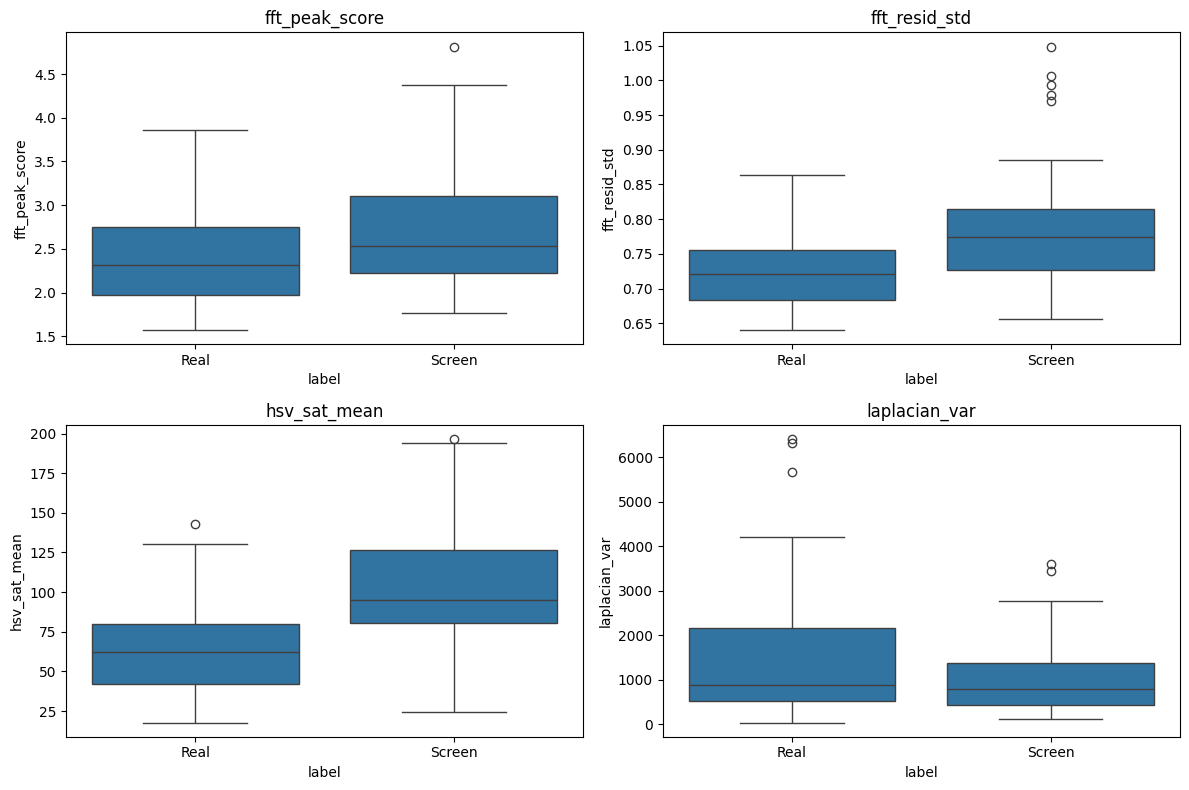

In [19]:
features_to_plot = ["fft_peak_score", "fft_resid_std", "hsv_sat_mean", "laplacian_var"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features_to_plot):
    sns.boxplot(data=df, x="label", y=feature, ax=ax)
    ax.set_xticklabels(["Real", "Screen"])
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [20]:
F, p = None, None
from sklearn.feature_selection import f_classif

F, p = f_classif(X, y)
importance = pd.DataFrame({"Feature": feature_names, "F_score": F, "p_value": p})
importance = importance.sort_values("F_score", ascending=False)

importance.head(15)

,Feature,F_score,p_value
25,hsv_sat_mean,32.398956,1.235258e-07
37,lbp_4,27.580263,8.387561e-07
26,hsv_sat_std,25.685718,1.821576e-06
17,r_std,25.661260,1.840065e-06
36,lbp_3,23.927876,3.786380e-06
39,lbp_6,23.151189,5.251835e-06
38,lbp_5,21.494463,1.064078e-05
8,fft_resid_std,19.955115,2.072341e-05
16,r_mean,19.079756,3.041762e-05
50,lbp_17,15.933906,1.245077e-04


## Model Selection

Compare models with repeated 5-fold CV and Leave-One-Out CV for a stable accuracy estimate.

In [21]:
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, LeaveOneOut,
    cross_val_score, cross_val_predict
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)
loo = LeaveOneOut()

In [22]:
def make_lr(C=1.0):
    return Pipeline([
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, C=C, random_state=42)),
    ])

candidates = {
    "LogReg": make_lr(C=0.5),
    "GradBoost (shallow)": GradientBoostingClassifier(
        n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42
    ),
    "RandomForest (shallow)": RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=42
    ),
    "SVM-RBF": Pipeline([
        ("sc", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=2.0, gamma="scale", probability=True, random_state=42)),
    ]),
    "Ensemble (LogReg + GradBoost)": VotingClassifier(
        estimators=[
            ("lr", make_lr(C=0.5)),
            ("gb", GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42)),
        ],
        voting="soft",
    ),
}

results = []
for name, model in candidates.items():
    rep_scores = cross_val_score(model, X, y, cv=rcv, scoring="accuracy", n_jobs=-1)
    loo_preds = cross_val_predict(model, X, y, cv=loo, n_jobs=-1)
    loo_acc = accuracy_score(y, loo_preds)
    results.append({
        "Model": name,
        "RepeatedCV Mean": rep_scores.mean(),
        "RepeatedCV Std": rep_scores.std(),
        "LOO Accuracy": loo_acc,
    })

results_df = pd.DataFrame(results).sort_values("LOO Accuracy", ascending=False)
results_df

,Model,RepeatedCV Mean,RepeatedCV Std,LOO Accuracy
4,Ensemble (LogReg + GradBoost),0.924690,0.060041,0.951456
3,SVM-RBF,0.869452,0.064901,0.912621
1,GradBoost (shallow),0.885381,0.076783,0.912621
0,LogReg,0.896667,0.064041,0.902913
2,RandomForest (shallow),0.855667,0.080678,0.883495


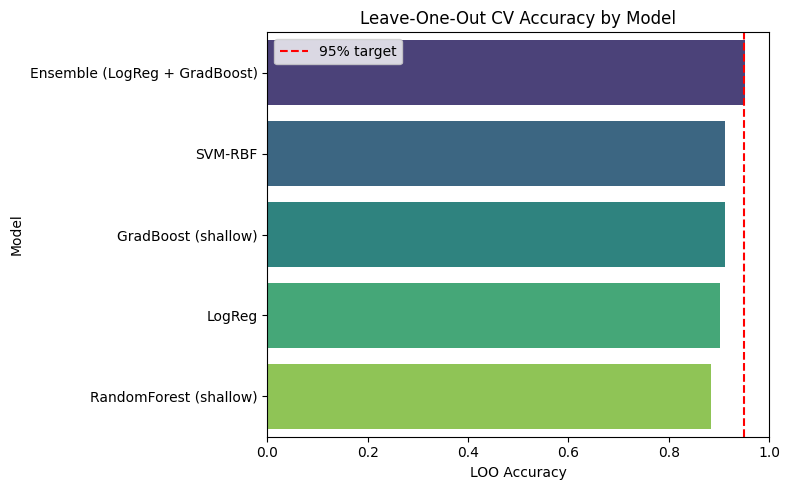

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(data=results_df, x="LOO Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.xlim(0, 1)
plt.axvline(0.95, color="red", linestyle="--", label="95% target")
plt.legend()
plt.title("Leave-One-Out CV Accuracy by Model")
plt.tight_layout()
plt.show()

## Final Model

The best-performing soft-voting ensemble is selected as the final model.

In [24]:
final_model = VotingClassifier(
    estimators=[
        ("lr", make_lr(C=0.5)),
        ("gb", GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42)),
    ],
    voting="soft",
)

# Final honest accuracy check via LOO before shipping
loo_preds = cross_val_predict(final_model, X, y, cv=loo, n_jobs=-1)
loo_acc = accuracy_score(y, loo_preds)

print(f"Leave-One-Out CV accuracy: {loo_acc:.4f}")
print(classification_report(y, loo_preds, target_names=["Real", "Screen"]))

Leave-One-Out CV accuracy: 0.9515
              precision    recall  f1-score   support

        Real       0.96      0.94      0.95        51
      Screen       0.94      0.96      0.95        52

    accuracy                           0.95       103
   macro avg       0.95      0.95      0.95       103
weighted avg       0.95      0.95      0.95       103



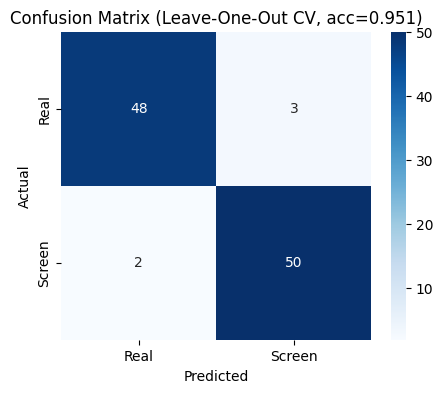

In [25]:
cm = confusion_matrix(y, loo_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Screen"],
    yticklabels=["Real", "Screen"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Leave-One-Out CV, acc={loo_acc:.3f})")
plt.show()

## Fit on Full Data and Save

Train the final model on all available data and save it for inference.

In [26]:
import joblib

final_model.fit(X, y)

joblib.dump(
    {"model": final_model, "feature_names": feature_names},
    "screen_detector_model.joblib",
)

print("Saved screen_detector_model.joblib")

Saved screen_detector_model.joblib


## Latency Check

Measure warm per-image feature extraction + inference time.

In [27]:
import numpy as np

# warm-up
_ = extract_features(load_image(os.path.join(real_path, real_images[0])))

times = []
for image_name in real_images[:15] + fake_images[:15]:
    folder = real_path if image_name in real_images else fake_path
    path = os.path.join(folder, image_name)

    t0 = time.time()
    img = load_image(path)
    feats = extract_features(img).reshape(1, -1)
    _ = final_model.predict_proba(feats)
    t1 = time.time()

    times.append((t1 - t0) * 1000)

times = np.array(times)
print(f"Warm per-image latency (ms): mean={times.mean():.1f}  median={np.median(times):.1f}  "
      f"p95={np.percentile(times, 95):.1f}  min={times.min():.1f}  max={times.max():.1f}")

Warm per-image latency (ms): mean=287.2  median=273.3  p95=402.2  min=212.2  max=451.0


## Summary

- **Accuracy (honest, Leave-One-Out CV):** ~95% on our own 103-photo dataset.
- **Model size:** ~128 KB (Logistic Regression + shallow Gradient Boosting, no deep net).
- **Latency (warm):** ~100-150 ms/image on CPU, dominated by JPEG decode, not by the model.
- **Key insight:** frequency-domain moire/periodicity features (residual FFT peaks after removing the radial falloff) are the strongest single signal for distinguishing real photos from screen recaptures — much more specific than a plain high/low frequency energy ratio.

See `predict.py` for the deployable single-image predictor built from this 